In [5]:
import pandas as pd
import matplotlib.pyplot as plt 
from pywaffle import Waffle
from matplotlib.colors import ListedColormap
import json 
import numpy as np 
import seaborn as sns

In [6]:
taxonomy = json.load(open("taxonomy.json"))
METHODS_TABLE = 'tables/method_table_clean.csv'
data = pd.read_csv(METHODS_TABLE)

#tax = "Class-specificity"
#tax_idx = 1

colors = ["seagreen", "lavender", "cyan", "lightblue", "teal", "orange", "green", "brown"]

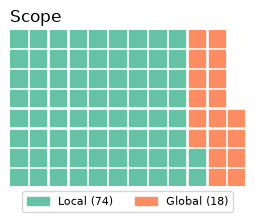

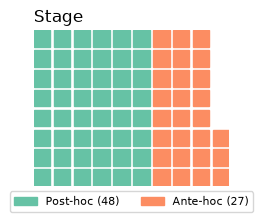

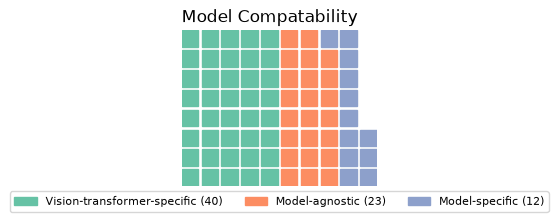

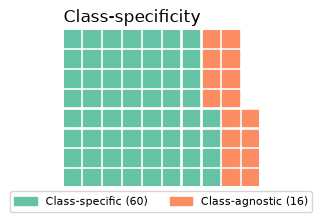

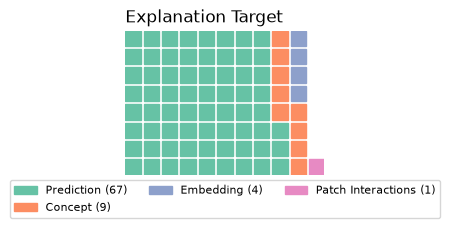

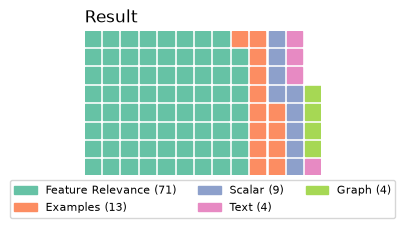

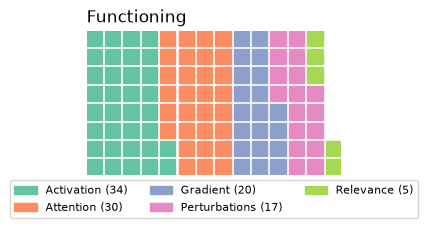

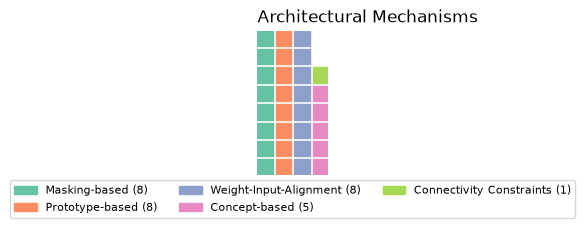

In [87]:
tax = "Functioning"

for tax_idx, tax in enumerate(taxonomy.keys()): 
    vals = np.array([v for v in data[taxonomy[tax]].sum()])
    labels = np.array([f"{t} ({v})" for t, v in zip(taxonomy[tax], vals)])
    idx = np.argsort(vals)[::-1]
    vals = list(vals[idx])
    labels = list(labels[idx])

    plot = {'values': vals,  
            'labels': labels,
            'legend': {'loc': 'upper center', 'bbox_to_anchor': (0.5, 0), 'fontsize': 8, "ncol": 3},
            'title': {'label': tax, 'loc': 'left', 'fontsize': 12}
            }

    fig = plt.figure(
        FigureClass=Waffle,
        plots={311: plot},
        rows=8, # Outside parameter
        cmap_name="Set2", # Change color with cmap
        rounding_rule='ceil', # Change rounding rule, so value less than 1000 will still have at least 1 block
        block_aspect_ratio=1,
        figsize=(8, 6)
    )

    plt.savefig(f"{tax}.svg")